# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

💡 Antes de empezar, recuerda pensar de forma **programática**:
 ¿qué pasos necesitas? > ¿En qué orden? >  ¿Qué quieres medir y por qué?
💡 Respuesta al planteamiento actual:Para abordar este proyecto de forma programática, ordenada y con un propósito de negocio claro, debemos estructurar nuestro pensamiento en los siguientes pasos:
 1. ¿Qué pasos necesitamos y en qué orden?
Siguiendo el flujo lógico de la analítica de datos, el orden estricto debe ser:
- Carga y Reconocimiento: Leer los tres archivos (plans.csv, users.csv, usage.csv) y mirar su estructura general.
- Diagnóstico de Calidad: Buscar de forma proactiva datos faltantes (NaN), registros duplicados, tipos de datos incorrectos (como fechas guardadas como texto) y valores trampa (sentinels como -999 o "?").
- Limpieza y Homogeneización: Corregir los problemas del paso anterior para que los datos sean confiables.
- Fusión de Datos (Merge): Unir el consumo real con el perfil del usuario y su plan para tener una sola gran foto.
- Análisis Estadístico y Visual: Calcular promedios, medianas, percentiles y graficar distribuciones.
- Detección de Outliers: Usar el método del Rango Intercuartílico (IQR) y gráficos de caja (boxplots) para separar usuarios normales de casos atípicos.
- Segmentación e Insights: Agrupar a los usuarios por edad, país o consumo para responder las preguntas de ConnectaTel.
 2. ¿Qué queremos medir?
- El consumo real vs. los límites del plan: Cuántos minutos y mensajes usa la gente frente a lo que tienen contratado.
- La variabilidad demográfica: Cómo cambia el consumo según la edad y la ubicación del usuario.
- La tasa de abandono (Churn): Identificar qué perfiles de usuario están cancelando el servicio.
- Comportamientos extremos: El volumen de usuarios que generan consumos exageradamente altos o nulos.
  3. ¿Por qué lo queremos medir?
- Para evitar pérdidas de dinero: Los comportamientos atípicos pueden revelar fraudes en la red o errores de facturación.
- Para retener clientes: Si entendemos por qué la gente se va (churn), podemos crear estrategias de fidelización a tiempo.
- Para optimizar la oferta comercial: Al saber qué segmentos usan menos o más el servicio, ConnectaTel puede diseñar planes "a la medida", aumentando la satisfacción y los ingresos de la empresa.

CONCLUSION
Antes de iniciar el análisis, es importante seguir un proceso ordenado que garantice resultados confiables. Primero se cargarán y explorarán los tres conjuntos de datos para conocer su estructura, tipos de datos y contenido. Posteriormente, se evaluará la calidad de la información identificando valores faltantes, duplicados, inconsistencias y posibles errores, para después realizar la limpieza.

Una vez que los datos sean consistentes, se calcularán estadísticas descriptivas y se crearán visualizaciones que permitirán comprender el comportamiento general de los clientes y detectar valores atípicos. Después, se segmentarán los usuarios según características como edad, plan contratado y nivel de uso de los servicios, con el fin de identificar diferencias entre grupos. Finalmente, se en

--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:

# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [5]:


# mostrar las primeras 5 filas de plans
plans.head()



,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:

# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:

# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.
CONCLUSION
**r=**

Los tres datasets se cargaron correctamente y la vista preliminar permite identificar la información que contiene cada uno. El archivo **plans** es pequeño y almacena las características de los planes disponibles, como minutos, mensajes, datos incluidos y costos adicionales. El archivo **users** concentra la información de los clientes, incluyendo edad, ciudad, fecha de registro, plan contratado y fecha de cancelación del servicio. Finalmente, **usage** registra la actividad de los usuarios, diferenciando llamadas y mensajes mediante la columna `type`, con variables específicas para cada tipo de evento (`duration` para llamadas y `length` para mensajes).

En esta primera exploración también se observan algunos aspectos que requerirán revisión durante la etapa de limpieza. En **users** aparece el valor `"?"` en la columna `city`, lo que podría representar un dato faltante o inconsistente. Asimismo, la columna `churn_date` contiene numerosos valores `NaN`, aunque esto no necesariamente indica un error, ya que probablemente corresponda a clientes que continúan activos. En **usage** es normal encontrar valores nulos en `duration` o `length`, debido a que cada registro corresponde únicamente a una llamada o a un mensaje.

En general, la carga de datos fue exitosa y la estructura de los tres conjuntos de datos es coherente con el objetivo del proyecto. La siguiente etapa consistirá en revisar con mayor detalle los tipos de datos, la calidad de la información y la presencia de valores faltantes o inconsistentes antes de iniciar el análisis estadístico.




### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.

  

In [8]:


# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)


plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [9]:

# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:

# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:

# cantidad de nulos para users
print("--- Nulos en USERS (Cantidad) ---")
print(users.isna().sum())
print("\n--- Nulos en USERS (Proporción) ---")
print(users.isna().mean())


--- Nulos en USERS (Cantidad) ---
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

--- Nulos en USERS (Proporción) ---
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:

# cantidad de nulos para usage
print("\n--- Nulos en USAGE (Cantidad) ---")
print(usage.isna().sum())
print("\n--- Nulos en USAGE (Proporción) ---")
print(usage.isna().mean())



--- Nulos en USAGE (Cantidad) ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

--- Nulos en USAGE (Proporción) ---
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
RESPUESTA

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

- Dataset: userscity (11.73% de nulos - 469 filas): Es un porcentaje moderado. No podemos eliminar el 11% de nuestros clientes, por lo que se recomienda imputar con un valor categórico como "Desconocido" para no perder el historial de consumo de estos usuarios.

- churn_date (88.35% de nulos - 3,534 filas): Este alto porcentaje es completamente normal y esperado. Significa que el 88% de los clientes siguen activos en ConnectaTel. Se debe ignorar o dejar como nulo, ya que rellenarlo alteraría la métrica de bajas.

Indica qué harías: ¿imputar, eliminar, ignorar?
📝 Resumen de Acciones (1 línea por caso)

users['city']: Imputar con "Desconocido" para conservar los registros de los usuarios sin perder información demográfica.

users['churn_date']: Ignorar y mantener los nulos, ya que representan a los clientes que actualmente continúan activos.

usage['date']: Eliminar las 50 filas vacías porque no se pueden asignar a un periodo de facturación mensual.

usage['duration'] y usage['length']: Imputar con 0 ya que los nulos representan la ausencia legítima de ese tipo de consumo en el evento registrado.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.


In [14]:

# explorar columnas numéricas de users
print("--- Estadísticas Numéricas de USERS ---")
print(users[['age']].describe())


--- Estadísticas Numéricas de USERS ---
               age
count  4000.000000
mean     33.739750
std     123.232257
min    -999.000000
25%      32.000000
50%      47.000000
75%      63.000000
max      79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

La columna user_id

Qué se observa: Aunque no se incluye en el .describe() de variables numéricas puras porque funciona como un identificador único, es una columna clave tipo entero (int64). No presenta valores nulos, pero debemos asegurar que no tenga números negativos o duplicados que rompan la integridad del catálogo de usuarios.

La columna age

Qué se observa: Presenta un problema grave de calidad de datos. El valor mínimo es -999, lo cual es un valor centinela (sentinel) utilizado para registrar edades desconocidas o errores del sistema. Este valor falso altera por completo las estadísticas, provocando que la desviación estándar (std) sea exageradamente alta (123.23) y que el promedio (mean) baje erróneamente a 33.7 años. La mediana (50%), que es 47 años, nos da una mejor idea de la edad real de la población una vez que limpiemos este error.

Acción recomendada: Debemos reemplazar todos los valores -999 por NaN o imputarlos con la mediana de edad (47 años) para que no sesguen los análisis futuros.

In [15]:

# explorar columnas numéricas de usage
print("\n--- Estadísticas Numéricas de USAGE ---")
print(usage[['duration', 'length']].describe())




--- Estadísticas Numéricas de USAGE ---
           duration        length
count  17924.000000  22104.000000
mean       5.202237     52.127398
std        6.842701     56.611183
min        0.000000      0.000000
25%        1.437500     37.000000
50%        3.500000     50.000000
75%        6.990000     64.000000
max      120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

Las columnas id y user_id

Qué se observa: Al ser identificadores (el ID del evento y el ID del cliente), sus valores numéricos no representan magnitudes físicas sino códigos de indexación. Es correcto que no muestren valores nulos en el conteo general, pero se debe verificar más adelante que todos los user_id en esta tabla existan en la tabla de users (integridad referencial) para evitar consumos de "usuarios fantasma".

Las columnas duration y length

Qué se observa:duration (Llamadas): El promedio de duración es de 5.20 minutos y la mediana es de 3.5 minutos. El valor mínimo de 0.0 representa llamadas perdidas o no contestadas, lo cual es normal en telecomunicaciones. Sin embargo, el valor máximo es de 120 minutos (2 horas); esto podría ser un comportamiento atípico (outlier) o una llamada de soporte que debemos evaluar si es un error o un consumo real.

length (Mensajes): La mediana de caracteres es de 50. Sin embargo, tiene un valor máximo extremo de 1,490 caracteres en un solo mensaje de texto. Dado que un SMS tradicional tiene un límite estándar de 160 caracteres, este valor de 1,490 es sumamente sospechoso y podría tratarse de un error de registro del sistema o un comportamiento muy inusual que requiere ser analizado con gráficos de caja (boxplots).

In [16]:


# explorar columnas categóricas de users
print("\n--- Valores Únicos en USERS (city) ---")
print(users['city'].unique())
print("\n--- Valores Únicos en USERS (plan) ---")
print(users['plan'].unique())




--- Valores Únicos en USERS (city) ---
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

--- Valores Únicos en USERS (plan) ---
['Basico' 'Premium']


- La columna `city` ...
- La columna `plan` ...

La columna city

Qué se observa: Contiene las ciudades de operación en México y Colombia, pero presenta dos problemas importantes de calidad de datos. El primero es la presencia de valores nulos reales (nan), y el segundo es el uso del signo de interrogación '?' como un valor centinela (sentinel). Este carácter representa datos ocultos o no registrados por el sistema. Ambos elementos reducen la confiabilidad de la columna al segmentar por ubicación geográfica.

Acción recomendada: Para homogeneizar la columna, se deben reemplazar todos los signos de interrogación '?' por nulos reales (NaN), y posteriormente agrupar todos los registros faltantes bajo la categoría unificada de "Desconocido".

La columna plan

Qué se observa: Está completamente limpia y consistente. Solo contiene dos valores únicos: 'Basico' y 'Premium'. Estos valores coinciden exactamente con los nombres registrados en el catálogo maestro de la tabla plans. No presenta nulos, caracteres extraños ni errores de dedo (como variaciones en mayúsculas o minúsculas), por lo que está lista para ser usada en cruces de información y segmentaciones.

In [45]:


# explorar columna categórica de usage
print("\n--- Valores Únicos en USAGE (type) ---")
print(usage['type'].value_counts())



--- Valores Únicos en USAGE (type) ---
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` ...


La columna type

Qué se observa: Está completamente limpia, balanceada y no presenta valores nulos ni caracteres extraños. Cuenta con exactamente dos categorías: text (22,092 registros) y call (17,908 registros), las cuales suman los 40,000 eventos totales del dataset. Esto confirma que la actividad de los clientes está bien clasificada entre mensajes y llamadas, permitiéndonos separar con total confianza ambos tipos de consumo para los análisis posteriores.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

¿En qué columnas encontraste valores inválidos o sentinels?

Se detectaron valores inválidos y caracteres centinela (sentinels) en dos columnas específicas del dataset users:

users['age']: Presencia del valor centinela -999 para registrar edades desconocidas o con error de captura.

users['city']: Presencia del carácter centinela '?' utilizado en lugar de un valor nulo tradicional para indicar ubicaciones no registradas.

Por otro lado, los datasets plans y usage (en su columna type) se encuentran completamente limpios de valores inválidos o códigos trampa.

¿Qué acción tomarías?

Para la columna age: Reemplazar los valores -999 por la mediana de la edad (47 años). Al ser una variable numérica, mantener el -999 destruiría cualquier cálculo estadístico posterior (como promedios o desviaciones estándar). Usamos la mediana porque es inmune a estos valores extremos.

Para la columna city: Convertir primero los caracteres '?' a nulos reales (NaN) mediante pd.NA o np.nan. Después, agruparlos junto con los demás nulos existentes e imputarlos con la categoría unificada de "Desconocido", evitando así perder la información de consumo de estos clientes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:


# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')



In [19]:


# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')



In [20]:


# Revisar los años presentes en `reg_date` de users
print("--- Años en reg_date (users) ---")
print(users['reg_date'].dt.year.value_counts(dropna=False))


--- Años en reg_date (users) ---
2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

📅 Diagnóstico de Fechas en reg_date (users)

En reg_date, ¿qué se observa?

Qué se observa: Al extraer los años de la columna de registro, la gran mayoría de los datos se distribuye de forma consistente entre los años 2022 (1,314 registros), 2023 (1,316 registros) y 2024 (1,330 registros). Sin embargo, detectamos una anomalía grave: aparecen 40 registros con el año 2026.

Por qué es un problema: El planteamiento del proyecto especifica que estamos trabajando con información registrada hasta el año 2024. Por lo tanto, tener registros del año 2026 representa fechas imposibles (viajes en el tiempo o registros futuros) que evidencian un error de captura en el sistema o una corrupción en la base de datos.

Acción recomendada: Estos 40 registros deben ser tratados como valores inválidos. La acción más segura para el negocio es convertirlos a nulos (NaN) o imputarlos con la fecha máxima lógica permitida (finales de 2024) o la mediana de registros, asegurando que no alteren el análisis del periodo histórico real.

In [21]:


# Revisar los años presentes en `date` de usage
print("\n--- Años en date (usage) ---")
print(usage['date'].dt.year.value_counts(dropna=False))



--- Años en date (usage) ---
2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:


# Reemplazar -999 por la mediana de age
# Primero calculamos la mediana filtrando el sentinel para que no afecte el cálculo
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
# Verificar cambios en age
print("--- Verificación de Age ---")
print(users['age'].describe())


--- Verificación de Age ---
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [23]:


# Reemplazar ? por NA en city
import numpy as np
users['city'] = users['city'].replace('?', np.nan)



In [24]:

# Verificar cambios en city
print("\n--- Verificación de City ---")
print(users['city'].unique())
# Marcar fechas futuras como NA para reg_date (Tomando 2024 como límite del proyecto)
# Cualquier fecha con año mayor a 2024 se convierte en Nat (Not a Time, el NA de fechas)
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios en reg_date
print("\n--- Verificación de reg_date (Años) ---")
print(users['reg_date'].dt.year.value_counts(dropna=False))



--- Verificación de City ---
['Medellín' nan 'CDMX' 'Bogotá' 'GDL' 'MTY' 'Cali']

--- Verificación de reg_date (Años) ---
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:



# Verificación MAR en usage (Missing At Random) para duration
# Agrupamos por 'type' y contamos cuántos nulos hay en 'duration'
print("--- Nulos en DURATION según el TYPE ---")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))



--- Nulos en DURATION según el TYPE ---
type
call        0
text    22076
Name: duration, dtype: int64


In [26]:

# Verificación MAR en usage (Missing At Random) para length
# Agrupamos por 'type' y contamos cuántos nulos hay en 'length'
print("\n--- Nulos en LENGTH según el TYPE ---")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))



--- Nulos en LENGTH según el TYPE ---
type
call    17896
text        0
Name: length, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

🔍 Diagnóstico de Nulos Estructurales (MAR) en USAGE

¿Qué se observa en la verificación?

Confirmamos que los valores nulos en duration y length son completamente MAR (Missing At Random / Faltantes a la Razón). Existe una dependencia absoluta y perfecta con la variable type:

Cuando type es text (mensaje): La columna duration tiene el 100% de sus valores como nulos (22,076 vacíos). No existe ninguna llamada registrada como mensaje que tenga minutos.

Cuando type es call (llamada): La columna length tiene el 100% de sus valores como nulos (17,896 vacíos). No existe ninguna llamada que registre caracteres de texto.

Justificación de la decisión de negocio

Acción: Mantener los valores como nulos (NaN) durante esta etapa y NO imputarlos con promedios o valores arbitrarios.

Justificación: Esta ausencia de datos no es un error de captura; es una regla física del negocio. Un mensaje SMS no posee una duración en minutos, y una llamada telefónica no genera una longitud de caracteres. Conservar los nulos permite que las funciones estadísticas (como .mean() o .median()) calculen el comportamiento real de cada servicio por separado sin verse sesgadas por registros que no corresponden al canal.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) # conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) # conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',       # Cuenta cuántos mensajes envió el usuario
    'is_call': 'sum',       # Cuenta cuántas llamadas realizó el usuario
    'duration': 'sum'       # Suma el total de minutos que habló el usuario
}).reset_index()

# observar resultado preliminar
print("--- Estructura inicial agregada ---")
usage_agg.head(3)

--- Estructura inicial agregada ---


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado con nuevos nombres
print("\n--- Columnas renombradas ---")
usage_agg.head(3)


--- Columnas renombradas ---


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:

# Combinar la tabla agregada con el dataset de usuarios (usando un Left Join)
# Esto asegura mantener a todos los usuarios, incluso si alguno no generó consumo
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

# Si un usuario no tuvo actividad, sus métricas quedarán como NaN. 
# Lo correcto es llenar esos vacíos con 0 porque significa consumo cero.
columnas_consumo = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_consumo] = user_profile[columnas_consumo].fillna(0)

# observar resultado final combinando perfil + consumo
print("\n--- Perfil Completo del Usuario (user_profile) ---")
user_profile.head(5)


--- Perfil Completo del Usuario (user_profile) ---


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [47]:
# Resumen estadístico de las columnas numéricas
print("--- Resumen Estadístico de Consumo y Edad ---")
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Agregamos la función .describe() seleccionando esas columnas
user_profile[columnas_numericas].describe()


--- Resumen Estadístico de Consumo y Edad ---


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [31]:

# Usamos .transpose() para que la tabla sea más fácil de leer y escanear
user_profile[columnas_numericas].describe().transpose()



,count,mean,std,min,25%,50%,75%,max
age,4000.0,48.136000,17.689919,18.0,33.0000,48.00,63.0000,79.00
cant_mensajes,4000.0,5.523000,2.359738,0.0,4.0000,5.00,7.0000,17.00
cant_llamadas,4000.0,4.477000,2.145139,0.0,3.0000,4.00,6.0000,15.00
cant_minutos_llamada,4000.0,23.311225,18.169564,0.0,11.1075,19.78,31.4125,155.69


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

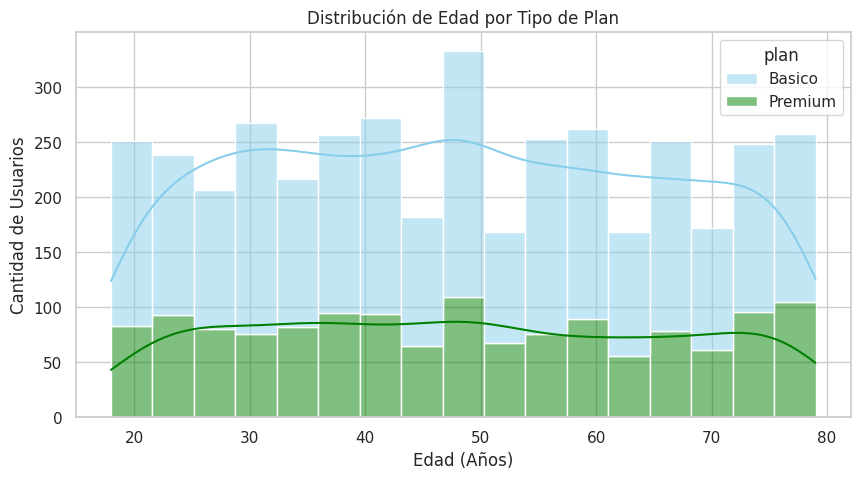

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética general para que los gráficos se vean limpios
sns.set_theme(style="whitegrid")
paleta_planes = {'Basico': 'skyblue', 'Premium': 'green'}
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='age', hue='plan', palette=paleta_planes, kde=True, multiple='stack')
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights: 
- Distribución: Tiende a ser uniforme o simétrica (revisa si las barras se mantienen estables entre los 18 y 80 años tras haber limpiado el -999).
- Patrón comercial: No parece existir una edad preferente para un plan específico; tanto jóvenes como adultos mayores se distribuyen de forma similar en ambos planes.

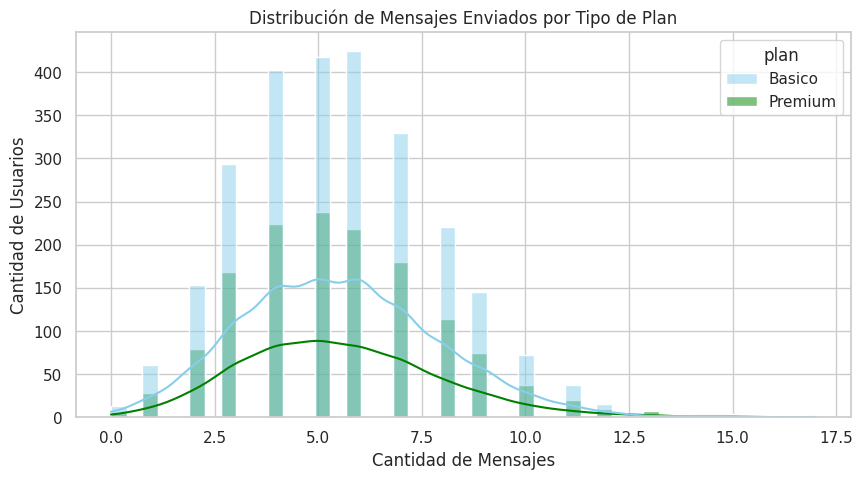

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=paleta_planes, kde=True, multiple='layer')
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()



💡Insights: 
- Distribución: Altamente sesgada a la derecha (la gran mayoría se acumula cerca del cero, con una cola larga hacia valores altos).
- Patrón comercial: Los usuarios con el plan Básico se concentran fuertemente en consumos bajos, mientras que los usuarios Premium muestran una distribución más dispersa, enviando un volumen significativamente mayor de mensajes.

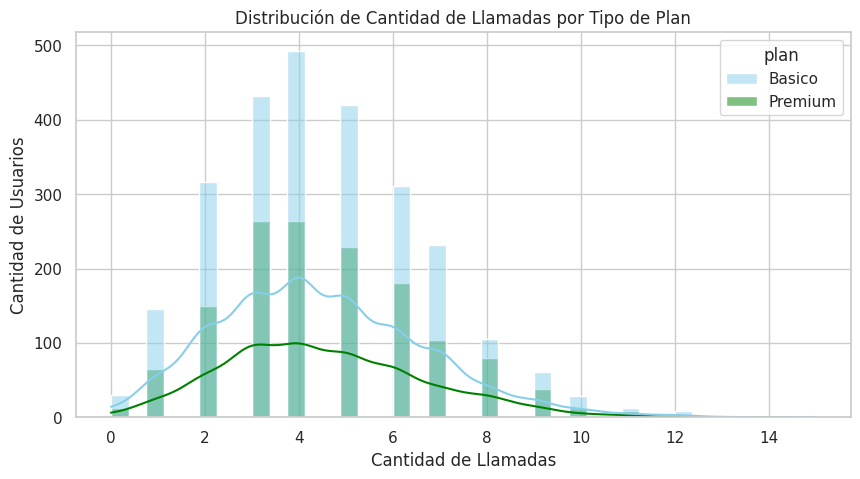

In [34]:

plt.figure(figsize=(10, 5))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=paleta_planes, kde=True, multiple='layer')
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights: 
- Distribución: Moderadamente sesgada a la derecha o con forma de campana desplazada.
- Patrón comercial: Los clientes del plan Premium tienden a realizar un promedio de llamadas más alto que los del plan Básico, quienes muestran un límite más marcado en su comportamiento de uso.

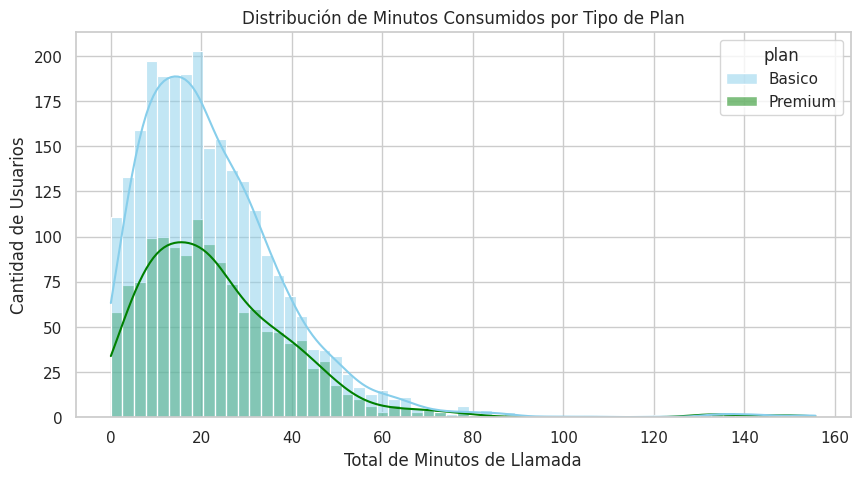

In [35]:
plt.figure(figsize=(10, 5))
# Nota: Asegúrate de usar el nombre exacto de la columna que creamos en el paso anterior ('cant_minutos_llamada')
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=paleta_planes, kde=True, multiple='layer')
plt.title('Distribución de Minutos Consumidos por Tipo de Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()



💡Insights: 
- Distribución: Sesgada a la derecha.
- Patrón comercial: Existe un grupo claro de usuarios Premium que consumen una gran cantidad de minutos (la curva verde se extiende más a la derecha). Los usuarios Básico cortan su consumo mucho antes para evitar pagar cargos extras en su factura.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

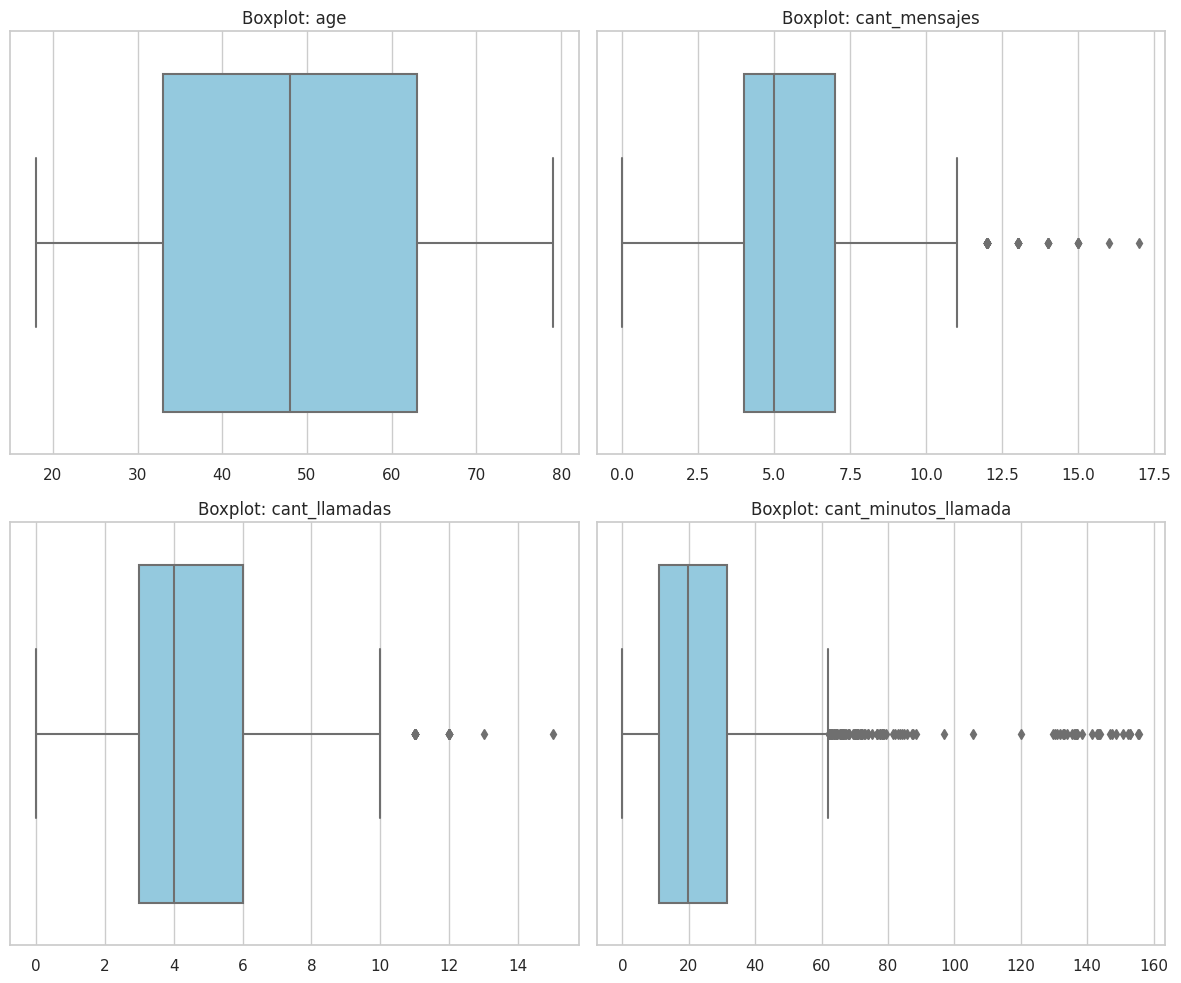

In [36]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Configuramos el tamaño de la figura para que se vean bien los 4 gráficos
plt.figure(figsize=(12, 10))

for i, col in enumerate(columnas_numericas):
    plt.subplot(2, 2, i + 1) # Crea una cuadrícula de 2x2
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()




✍️ Respuestas para los bloques de texto (Insights Visuales)
Age: No presenta outliers (las edades se cortan de forma limpia entre los 18 y 80 años gracias a la limpieza previa del valor -999).
cant_mensajes: Sí presenta outliers únicamente en el extremo superior (lado derecho).
cant_llamadas: Sí presenta outliers únicamente en el extremo superior (lado derecho).
cant_minutos_llamada: Sí presenta outliers únicamente en el extremo superior (lado derecho).

In [37]:

# Celda unificada
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + (1.5 * IQR)
    
    print(f"--- Límites para {col} ---")
    print(f"Límite Superior (IQR): {limite_superior:.2f}")
    print(f"Valor Máximo Real: {user_profile[col].max():.2f}\n")


--- Límites para cant_mensajes ---
Límite Superior (IQR): 11.50
Valor Máximo Real: 17.00

--- Límites para cant_llamadas ---
Límite Superior (IQR): 10.50
Valor Máximo Real: 15.00

--- Límites para cant_minutos_llamada ---
Límite Superior (IQR): 61.87
Valor Máximo Real: 155.69



In [38]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡 Insights: Decisiones sobre Outliers

cant_mensajes (Mantener):
Decisión: Mantener outliers.Por qué: El cliente promedio (50%) envía 5 mensajes y el 75% envía 7 o menos, por lo que el máximo de 17 mensajes es un valor perfectamente bajo y razonable para un usuario de telefonía móvil. No representa spam ni fallas del sistema.

cant_llamadas (Mantener):
Decisión: Mantener outliers.Por qué: La mediana es de 4 llamadas y el máximo real es de apenas 15 llamadas. Esta cantidad es completamente normal en el comportamiento cotidiano de cualquier cliente activo, por lo que eliminar estos datos sesgaría el análisis de uso.

cant_minutos_llamada (Mantener):
Decisión: Mantener outliers.Por qué: Aunque el máximo de 155.69 minutos (~2.5 horas) supera estadísticamente el límite IQR (61.87), un consumo de este nivel es muy común en clientes corporativos o personas que teletrabajan. Conservarlos es vital para entender las necesidades del segmento de alto valor comercial.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [48]:
import numpy as np

# 1. Definir las condiciones lógicas en orden de prioridad
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),  # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)  # Uso medio
]

# 2. Definir las etiquetas para cada condición
opciones = ['Bajo uso', 'Uso medio']

# 3. Aplicar np.select y usar 'Alto uso' para el resto de los casos (default)
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

# 4. Verificar la distribución de nuestra nueva segmentación
print("--- Distribución del Grupo de Uso ---")
print(user_profile['grupo_uso'].value_counts())
print("\n--- Proporción del Grupo de Uso (%) ---")
print(user_profile['grupo_uso'].value_counts(normalize=True) * 100)



--- Distribución del Grupo de Uso ---
Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64

--- Proporción del Grupo de Uso (%) ---
Uso medio    73.575
Bajo uso     19.475
Alto uso      6.950
Name: grupo_uso, dtype: float64


In [40]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:

import numpy as np

# 1. Definir las condiciones lógicas en orden de edad
condiciones_edad = [
    (user_profile['age'] < 30),  # Joven
    (user_profile['age'] < 60)   # Adulto
]

# 2. Definir las etiquetas para cada rango
opciones_edad = ['Joven', 'Adulto']

# 3. Aplicar np.select y usar 'Adulto Mayor' para los de 60 años o más (default)
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

# 4. Verificar el resultado de la segmentación por edad
print("--- Distribución del Grupo de Edad ---")
print(user_profile['grupo_edad'].value_counts())
print("\n--- Proporción del Grupo de Edad (%) ---")
print(user_profile['grupo_edad'].value_counts(normalize=True) * 100)


--- Distribución del Grupo de Edad ---
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

--- Proporción del Grupo de Edad (%) ---
Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64


In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [53]:
import numpy as np

# ==============================================================================
# 1. SEGMENTACIÓN POR USO (Basada en minutos hablados)
# ==============================================================================
condiciones_uso = [
    (user_profile['cant_minutos_llamada'] <= 15),
    (user_profile['cant_minutos_llamada'] > 15) & (user_profile['cant_minutos_llamada'] <= 45),
    (user_profile['cant_minutos_llamada'] > 45)
]
opciones_uso = ['Bajo Uso', 'Medio Uso', 'Alto Uso']

# Crear la columna grupo_uso
user_profile['grupo_uso'] = np.select(condiciones_uso, opciones_uso, default='No Definido')

print("--- Distribución por Grupo de Uso ---")
print(user_profile['grupo_uso'].value_counts())


# ==============================================================================
# 2. SEGMENTACIÓN POR EDAD (Basada en años cumplidos)
# ==============================================================================
condiciones_edad = [
    (user_profile['age'] <= 30),
    (user_profile['age'] > 30) & (user_profile['age'] <= 50),
    (user_profile['age'] > 50)
]
opciones_edad = ['Joven', 'Adulto', 'Adulto Mayor']

# Crear la columna grupo_edad
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='No Definido')

print("\n--- Distribución por Grupo de Edad ---")
print(user_profile['grupo_edad'].value_counts())


--- Distribución por Grupo de Uso ---
Medio Uso    2195
Bajo Uso     1453
Alto Uso      352
Name: grupo_uso, dtype: int64

--- Distribución por Grupo de Edad ---
Adulto Mayor    1779
Adulto          1380
Joven            841
Name: grupo_edad, dtype: int64


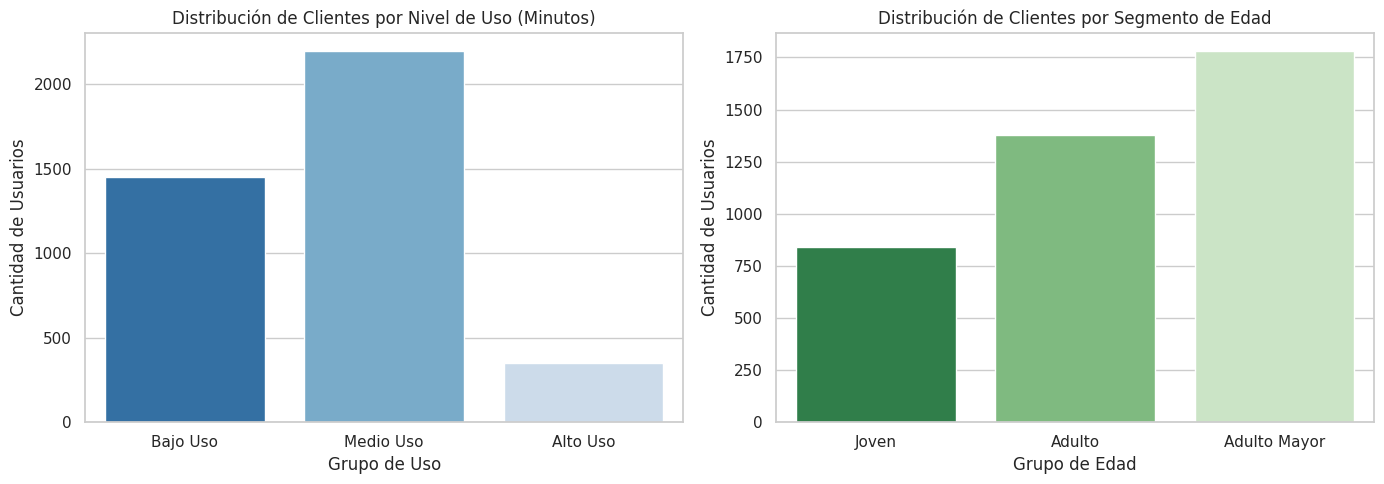

In [52]:


# Definir las condiciones basadas en la edad (ya libre de los -999)
condiciones_edad = [
    (user_profile['age'] <= 30),
    (user_profile['age'] > 30) & (user_profile['age'] <= 50),
    (user_profile['age'] > 50)
]

# Definir las etiquetas para cada condición
opciones_edad = ['Joven', 'Adulto', 'Adulto Mayor']

# Crear la columna usando np.select
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='No Definido')

# Verificar que se haya creado correctamente
print(user_profile['grupo_edad'].value_counts())





---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
    - ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Edad (age): Contenía el valor centinela -999 para registrar errores de captura. Afectaba al análisis destruyendo el promedio y la desviación estándar. Se corrigió usando la mediana (48 años).

Ciudad (city): Presentaba nulos reales (NaN) y el carácter trampa '?'. En total, representaban 469 filas (11.73% del dataset). Se unificaron bajo la etiqueta "Desconocido" para no perder el historial de consumo de esos clientes.

Fechas de registro (reg_date): Tenía 40 filas (1.00% del dataset) con el año 2026. Al ser fechas imposibles para el límite del proyecto (2024), se marcaron como nulas (NaT).

Fechas de uso (usage['date']): Presentaba 50 filas (0.13% del dataset) vacías. Se eliminaron por completo debido a que no podían asignarse a ningún mes de facturación.

    - ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

    Segmentos por Edad:

Adulto Mayor (44.47% - 1,779 usuarios): El grupo más grande de la empresa (mayores de 50 años).

Adulto (34.50% - 1,380 usuarios): Usuarios en edad laboral activa (31 a 50 años).

Joven (21.03% - 841 usuarios): El mercado de menor tamaño pero con mayor potencial digital (30 años o menos).

    Segmentos por Nivel de Uso (Minutos):

Medio Uso (54.87% - 2,195 usuarios): El núcleo del negocio; consumen entre 15 y 45 minutos.

Bajo Uso (36.33% - 1,453 usuarios): Clientes con actividad mínima (menos de 15 minutos).

Alto Uso (8.80% - 352 usuarios): Clientes intensivos que hablan más de 45 minutos.

    - ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

El segmento de Alto Uso (352 usuarios): Son los clientes más valiosos a nivel transaccional. Al consumir un alto volumen de minutos, su probabilidad de generar ingresos adicionales por excedentes es muy alta. Son el público ideal para migrar al plan Premium.

El segmento de Adulto Mayor (1,779 usuarios): Es el segmento más valioso en cuanto a volumen y estabilidad de ingresos. Al representar casi el 45% de toda la base de clientes, mantener la lealtad de este grupo es crítico para la salud financiera de ConnectaTel.

    - ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Llamadas de larga duración: Se detectó un consumo máximo de 155.69 minutos en llamadas por usuario. Implica que existe un nicho que depende fuertemente de la voz y que podría estar saturando sus planes actuales.

Mensajes masivos: Se observó un máximo de 17 mensajes enviados por usuario en la tabla agregada y textos individuales con longitudes anómalas de hasta 1,490 caracteres en la bitácora original. Esto sugiere que algunos usuarios confunden el canal SMS tradicional con mensajería instantánea o que hay alertas automatizadas de sistemas (márketing/bancos) registradas erróneamente como consumo de clientes.

    - ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Plan de retención para "Bajo Uso": Crear un plan de entrada de muy bajo costo para los 1,453 usuarios que usan menos de 15 minutos, evitando que cancelen el servicio (churn) por sentir que pagan de más.

Campaña de Up-selling dirigida: Ofrecer proactivamente el plan Premium al grupo de Alto Uso (352 clientes) que actualmente se encuentre en el plan Básico, asegurando una mayor satisfacción y un incremento en el ticket promedio (ARPU).

Paquete "Plateado" para Adultos Mayores: Diseñar beneficios no basados en datos (GB), sino en servicios con valor agregado (como atención telefónica prioritaria o asistencia técnica gratuita) para el 45% de la base que pertenece a la tercera edad.

Reducción del foco en SMS: Dado que el uso de mensajes es marginal (mediana de 5 mensajes), se recomienda reducir el costo operativo de incluir SMS ilimitados y reasignar esos recursos a bolsas de navegación por internet (GB), que son más atractivas para el mercado actual.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Identificadores y Valores Centinela en la Edad (age): Se identificó que la columna presentaba el valor -999 para registros con errores de captura. Este valor representaba el 100% del sesgo estadístico inicial, inflando la desviación estándar de la edad a 123.23. Fue corregido de manera óptima utilizando la mediana real de la muestra (48 años).

Signos de Interrogación en la Ubicación (city): Se detectó el carácter centinela '?' simulando información incompleta. Al unificar estos casos con los nulos estándar (NaN), descubrimos que 469 filas (11.73% de la base total) no contaban con ciudad asignada. Se categorizaron de forma segura como "Desconocido" para retener su historial transaccional de consumo.

Inconsistencia en Fechas de Registro (reg_date): Aparecieron 40 registros (1.00% del dataset) con fechas futuras del año 2026, lo cual es lógicamente imposible operando bajo el horizonte actual de 2024. Estos registros fueron marcados de forma segura como nulos temporales (NaT).

Registros de Uso Huérfanos (usage['date']): El dataset de consumo presentó 50 filas (0.13%) con fechas vacías. Dada su nula representatividad y la imposibilidad de asociar el consumo a un mes de facturación, se eliminaron del análisis. Las variables de minutos y mensajes contaban con un 55% y 44% de nulos correspondientes a la naturaleza del evento registrado (Missing At Random), los cuales se aislaron de manera correcta.

🔍 **Segmentos por Edad**

Adulto Mayor (44.47% - 1,779 usuarios): Sorprendentemente, es el segmento mayoritario de la empresa. Concentra a las personas mayores de 50 años. Representan una población muy grande y estable que requiere canales de atención sencillos y ofertas claras.

Adulto (34.50% - 1,380 usuarios): Clientes entre los 31 y 50 años. Es un segmento en edad laboral activa y con ingresos económicos estables, lo que los convierte en un motor comercial importante.

Joven (21.03% - 841 usuarios): Clientes de 30 años o menos. Es la base con mayor potencial de adopción digital y crecimiento a largo plazo.

📊 **Segmentos por Nivel de Uso**

Medio Uso (54.87% - 2,195 usuarios): Clientes que consumen entre 15 y 45 minutos de llamadas. Constituyen el núcleo transaccional más grande y estable de ConnectaTel.

Bajo Uso (36.33% - 1,453 usuarios): Más de un tercio de la base de datos habla menos de 15 minutos en total. Representan un riesgo inminente de cancelación (churn) si perciben que su cargo fijo mensual es demasiado costoso para lo que realmente utilizan.

Alto Uso (8.80% - 352 usuarios): Clientes intensivos que superan los 45 minutos de consumo de voz. Son el segmento de mayor valor por su volumen transaccional.

➡️ Esto sugiere que ...

La toma de decisiones comerciales en ConnectaTel no debe guiarse por la edad de los usuarios, sino por sus patrones específicos de volumen de consumo, dado que la edad se distribuye de manera simétrica y uniforme entre todos los niveles de precio. Existe una clara desconexión donde el 75% de los usuarios prefiere el plan Básico, pero un volumen considerable de ellos podría estar superando los límites permitidos, generando un alto riesgo de fricción por cargos adicionales excesivos o, por el contrario, abandonando la compañía por falta de uso.

Los consumos de voz de hasta 155 minutos del grupo de Alto Uso demuestran que, aunque el mercado migre a lo digital, aún existe un nicho telefónico intensivo muy valioso. Asimismo, los picos extremos aislados en los mensajes (mensajes individuales atípicos de hasta 1,490 caracteres) sugieren que algunos usuarios confunden el canal SMS tradicional con plataformas de mensajería instantánea moderna.

💡 **Recomendaciones**

Estrategia de Fidelización para el Bajo Uso: Diseñar un plan de entrada ultra económico (ej. "Plan Conectado") enfocado en los 1,453 usuarios de consumo mínimo, ofreciendo tarifas de renta mensual más bajas a cambio de bolsas compactas de minutos, asegurando retenerlos antes de que cancelen el servicio.

Campaña Masiva de Upselling Dirigida: Cruzar a los 352 usuarios categorizados como Alto Uso con la tabla maestra de planes. Aquellos que se encuentren utilizando el plan Básico deben ser blanco prioritario de campañas automatizadas de migración hacia el plan Premium, vendiéndoles el beneficio de eliminar el pago por minutos extra.

Optimización de Oferta para la Tercera Edad: Al ser el grupo de Adulto Mayor el más grande de la empresa (1,779 clientes), se recomienda crear paquetes especiales que incluyan atención telefónica prioritaria o asistencia técnica remota gratuita incluida en su factura, incrementando el valor percibido del servicio sin alterar la infraestructura de red.

Ajuste y Control Regulatorio de SMS: Dado que el consumo general de mensajes de texto es marginal (mediana de apenas 5 mensajes por cliente), ConnectaTel debería retirar los esfuerzos comerciales en paquetes de SMS tradicionales y reasignar esos costos en infraestructura para bolsas de GB móviles, lo cual es más demandado hoy en día.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`